In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow import data as tf_data
import tensorflow as tf
from tensorflow.keras import layers, models
import keras

seed = 67
keras.utils.set_random_seed(seed)

In [2]:
# Number of classes
num_classes = 36 # 0-9 + A-Z

# 28x28 images
image_size = (28, 28)

# Validation split
validation_split = 0.2

# Batch size and epochs
batch_size = 48
max_epochs = 40

# Dropout
dropout = 0.4

In [4]:
# Load training data
df = pd.read_csv('sets/emnist-balanced-train.csv', header=None, delimiter=',')
df.dataframeName = 'emnist-balanced-train.csv'

# Load test data
df_test = pd.read_csv('sets/emnist-balanced-test.csv', header=None, delimiter=',')
df_test.dataframeName = 'emnist-balanced-test.csv'

# Clean out lowercase
df = df[df[0] < num_classes]
df_test = df_test[df_test[0] < num_classes]

# Load class mapping data into a dictionary
df_ascii_map = pd.read_csv('sets/emnist-balanced-mapping.txt', sep=' ', header=None, names=["class", "ascii"])
ascii_map = dict(zip(df_ascii_map["class"], df_ascii_map["ascii"]))
ascii_map = {k: chr(v) for k, v in ascii_map.items()}

df.head()
for k, v in ascii_map.items():
    print(f'{k}: "{v}",')

0: "0",
1: "1",
2: "2",
3: "3",
4: "4",
5: "5",
6: "6",
7: "7",
8: "8",
9: "9",
10: "A",
11: "B",
12: "C",
13: "D",
14: "E",
15: "F",
16: "G",
17: "H",
18: "I",
19: "J",
20: "K",
21: "L",
22: "M",
23: "N",
24: "O",
25: "P",
26: "Q",
27: "R",
28: "S",
29: "T",
30: "U",
31: "V",
32: "W",
33: "X",
34: "Y",
35: "Z",
36: "a",
37: "b",
38: "d",
39: "e",
40: "f",
41: "g",
42: "h",
43: "n",
44: "q",
45: "r",
46: "t",


In [ ]:
# Labels
y_train = df[0].values
y_test = df_test[0].values

# Images (Come transposed. Need to transpose back for mondel to be usable)
X_train = (df.iloc[:, 1:].values.reshape(-1, 28, 28).transpose(0, 2, 1).astype('float32') / 255.0)
X_test = (df_test.iloc[:, 1:].values.reshape(-1, 28, 28).transpose(0, 2, 1).astype('float32') / 255.0)

print(X_train.shape)
print(X_test.shape)
print(f"Number of classes: {len(tf.unique(y_train)[0])}")  # should be 36

(86400, 28, 28)
(14400, 28, 28)
Number of classes: 36


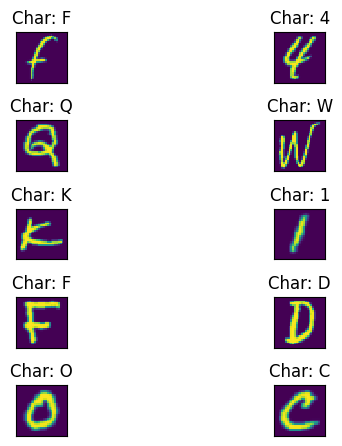

In [35]:
fig = plt.figure()
for i in range(10):
  plt.subplot(5,2,i+1)
  plt.tight_layout()
  plt.imshow(X_train[i], interpolation='none')
  plt.title("Char: {}".format(ascii_map[y_train[i]]))
  plt.xticks([])
  plt.yticks([])

In [40]:
input_shape = image_size + (1,)
model = models.Sequential([
    # 1st convolutional layer
    layers.Input(shape=input_shape),
    layers.Conv2D(num_classes, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # 2nd convolutional layer
    layers.Conv2D(num_classes * 2, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten to 1D
    layers.Flatten(),

    # Connected dense layers
    layers.Dense(num_classes * 4, activation='relu'),
    layers.Dropout(dropout),
    layers.Dense(num_classes * 2, activation='relu'),
    layers.Dropout(dropout),

    # Classification (dense layer)
    layers.Dense(num_classes, activation='softmax')
])
     
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 36)     │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 36)     │           144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 36)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 72)     │        23,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 72)     │           288 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 72)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 144)            │       259,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 72)             │        10,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 36)             │         2,628 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 296,604 (1.13 MB)

 Trainable params: 296,388 (1.13 MB)

 Non-trainable params: 216 (864.00 B)

In [54]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=max_epochs,
    validation_split=validation_split,
    callbacks=[early_stopping]
)

Epoch 1/40
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9272 - loss: 0.1919 - val_accuracy: 0.9444 - val_loss: 0.1304
Epoch 2/40
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9281 - loss: 0.1861 - val_accuracy: 0.9443 - val_loss: 0.1298
Epoch 3/40
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9298 - loss: 0.1811 - val_accuracy: 0.9429 - val_loss: 0.1377
Epoch 4/40
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9304 - loss: 0.1782 - val_accuracy: 0.9424 - val_loss: 0.1364
Epoch 5/40
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9318 - loss: 0.1746 - val_accuracy: 0.9421 - val_loss: 0.1369
Epoch 6/40
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9307 - loss: 0.1765 - val_accuracy: 0.9419 - val_loss: 0.1419
Epoch 7/40
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9327 - loss: 0.1731 - val_accuracy: 0.9407 - val_loss: 0.1437
Epoch 8/40
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9320 - loss: 0

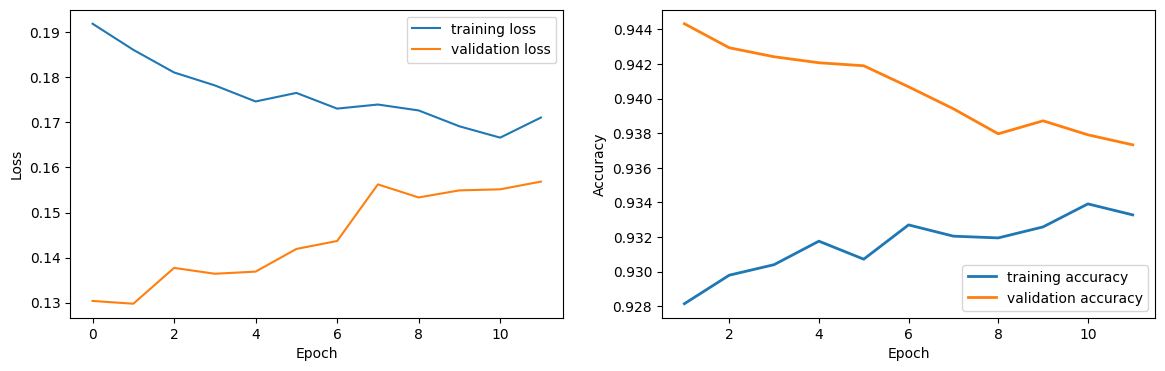

In [56]:
logs = pd.DataFrame(history.history)

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.plot(logs["loss"], label='training loss')
plt.plot(logs["val_loss"], label='validation loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(logs.loc[1:,"accuracy"], lw=2, label='training accuracy')
plt.plot(logs.loc[1:,"val_accuracy"], lw=2, label='validation accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')
plt.show()

In [58]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

450/450 - 1s - 2ms/step - accuracy: 0.9141 - loss: 0.3114

Final Test Accuracy: 91.41%


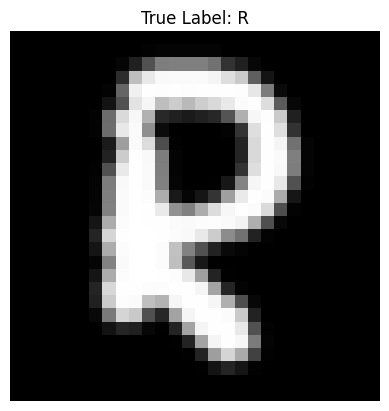

Predicted Digit: R
Confidence: 100.00%

All probabilities:
0: 0.00%
1: 0.00%
2: 0.00%
3: 0.00%
4: 0.00%
5: 0.00%
6: 0.00%
7: 0.00%
8: 0.00%
9: 0.00%
A: 0.00%
B: 0.00%
C: 0.00%
D: 0.00%
E: 0.00%
F: 0.00%
G: 0.00%
H: 0.00%
I: 0.00%
J: 0.00%
K: 0.00%
L: 0.00%
M: 0.00%
N: 0.00%
O: 0.00%
P: 0.00%
Q: 0.00%
R: 100.00%
S: 0.00%
T: 0.00%
U: 0.00%
V: 0.00%
W: 0.00%
X: 0.00%
Y: 0.00%
Z: 0.00%


In [76]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random test sample
idx = np.random.randint(0, len(X_test))

image = X_test[idx]
true_label = ascii_map[y_test[idx]]

# Display the image
plt.imshow(image, cmap='gray')
plt.title(f"True Label: {true_label}")
plt.axis('off')
plt.show()

# Prepare image for prediction
x = image.reshape(1, 28, 28)

# Get prediction probabilities
probs = model.predict(x, verbose=0)[0]

# Predicted digit
predicted_digit = np.argmax(probs)

print(f"Predicted Digit: {ascii_map[predicted_digit]}")
print(f"Confidence: {probs[predicted_digit]*100:.2f}%")

print("\nAll probabilities:")
for digit, prob in enumerate(probs):
    print(f"{ascii_map[digit]}: {prob*100:.2f}%")

300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


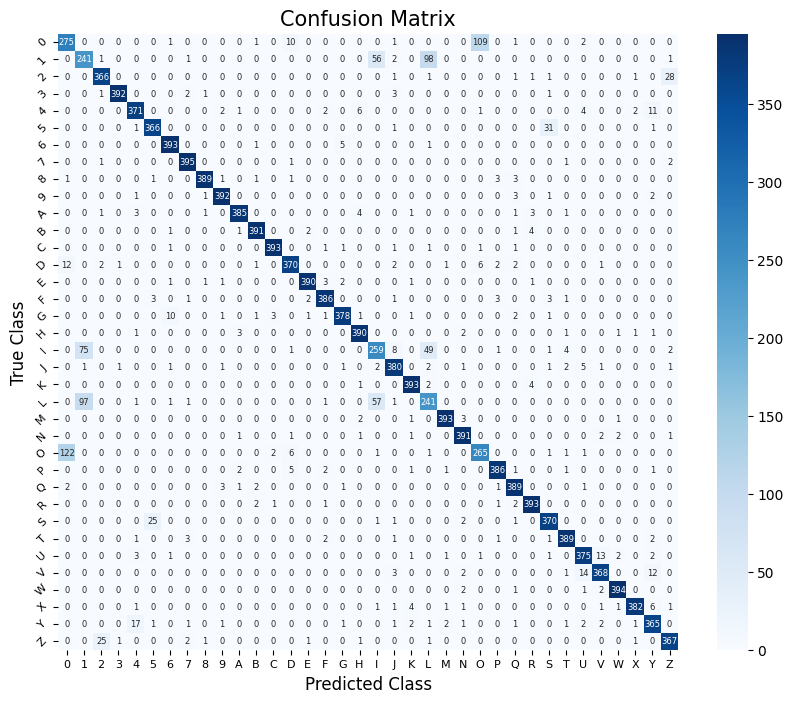

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_probs = model.predict(X_test, batch_size=batch_size, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Grab the ASCII values from the map as an array 
ascii_labels = list(ascii_map.values())[:36]

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=ascii_labels, yticklabels=ascii_labels,
    annot_kws={"size": 6}
) 

# Labels, titles, etc.
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title("Confusion Matrix", fontsize=15)

# Rotate y-axis ticks for readability, reduce font size so it fits
plt.xticks(fontsize=8)
plt.yticks(rotation=45, fontsize=8)
plt.show()

# Results
## Expected Issues
- 1 vs I vs L
- 0 vs O
- Z vs 2
- S vs 5
## Unexpected Issues
- 1 vs M


In [79]:
model.save("emnist_balanced_model.keras")